 1: What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each.


	K-Means Clustering

  Requires the number of clusters (k) to be specified before running.

  Divides data into mutually exclusive (non-overlapping) subsets.

  Highly efficient for large datasets (complexity).

  Performs best with spherical or globular clusters.

  Results can vary between runs due to random initialization of centroids.

  K-Means Use Case: Customer Segmentation
Application: A retail company wants to group millions of customers into distinct categories (e.g., "Budget Shoppers," "Premium Buyers," "Frequent Visitors") for targeted marketing.
Why K-Means: It is the ideal choice because the dataset is large, and the marketing team likely has a specific number of segments in mind to align with their budget and strategy.





Hierarchical Clustering

Does not require a pre-specified number of clusters; it discovers them

Computationally intensive , making it better for small datasets

More robust to varying shapes and sizes depending on the linkage method used.

Always produces the same results for the same data and parameters.


Organizes data into a nested tree-like hierarchy (dendrogram).


Hierarchical Clustering Use Case: Biological Taxonomy or Clinical Research
Application: Researchers studying evolutionary relationships between different species or categorizing patient populations based on genetic markers.
Why Hierarchical: It allows researchers to visualize the "natural" relationships and sub-relationships through a dendrogram. Since they might not know the exact number of species "groups" beforehand, the tree structure helps them decide where to "cut" the data to define clusters.



2: Explain the purpose of the Silhouette Score in evaluating clustering
algorithms.



The Silhouette Score is a metric used to measure how well each data point fits within its assigned cluster compared to other clusters. It helps you determine if your clusters are dense and well-separated.
The score for a single point is calculated using two factors:

Cohesion (a): The average distance between the point and all other points in the same cluster (you want this to be low).


Separation (b): The average distance between the point and all points in the nearest neighboring cluster (you want this to be high).


How to interpret the score:


The resulting value ranges from -1 to +1:
Near +1: The point is far from neighboring clusters and very close to its own. This indicates excellent clustering.


Near 0: The point is on or very close to the decision boundary between two clusters. This suggests overlapping clusters.


Near -1: The point has been assigned to the wrong cluster.


The Purpose
While methods like the Elbow Method only look at internal cluster tightness (inertia), the Silhouette Score evaluates both tightness and separation. This makes it a superior tool for:
Selecting the optimal
: The
 value with the highest average Silhouette Score is often the best choice.
Validating cluster quality: It provides a objective "grade" for how distinct your groups actually are.



 3: What are the core parameters of DBSCAN, and how do they influence the
clustering process?

The core parameters of DBSCAN (Density-Based Spatial Clustering of Applications with Noise) are Eps and MinPts. These parameters define the "density" required to form a cluster and directly influence how the algorithm identifies structures and handles noise


1. Eps (
 or Epsilon)
Definition: The maximum distance (radius) between two points for them to be considered neighbors.
Influence on Clustering:
If Eps is too small: Large portions of the data may be labeled as noise because points cannot "reach" each other to form a dense region.
If Eps is too large: Distinct clusters may merge into a single large group, failing to identify the true underlying structure.
Optimal Selection: Often determined using a K-distance graph; the "elbow" or "knee" of this plot typically indicates an ideal Eps value

2. MinPts (Minimum Points)
Definition: The minimum number of points required within an Eps-radius neighborhood to define that region as "dense" and mark the center point as a Core Point.
Influence on Clustering:
Higher MinPts: Makes the algorithm more conservative and robust to noise. It helps in identifying more significant, dense clusters while ignoring small, random fluctuations.
Lower MinPts: Allows smaller groups of points to form clusters. If set too low (e.g.,
), the result may resemble Hierarchical Clustering and become overly sensitive to noise.



3. Interplay & Point Classification
Together, these parameters categorize every data point into one of three types, as described in the Scikit-learn DBSCAN documentation:
Core Points: Have at least MinPts neighbors within Eps distance.
Border Points: Within Eps distance of a Core Point but do not have enough neighbors themselves to be "core".
Noise Points (Outliers):

 4: Why is feature scaling important when applying clustering algorithms like
K-Means and DBSCAN?


Feature scaling is critical because these algorithms rely on Euclidean distance to calculate similarity between data points. If your features have different scales, the variables with larger numerical ranges will dominate the distance calculation, making the smaller ones effectively invisible.

The Impact on Clustering
In K-Means: The algorithm tries to minimize the distance between points and centroids. If "Income" ranges from $0–$100,000 and "Age" ranges from 0–100, the distance calculation will be almost entirely driven by Income. K-Means will ignore Age, resulting in clusters that only reflect salary differences.


In DBSCAN: Since you must define a single radius (Eps) to find neighbors, having unscaled data makes it impossible to choose a value that works for all dimensions. A "distance of 5" might be huge for Age but insignificantly small for Income.


Common Scaling Methods
Standardization (Z-score): Centers data around a mean of 0 with a standard deviation of 1. This is usually the "go-to" for clustering.
Normalization (Min-Max): Rescales data to a fixed range, usually 0 to 1. This is helpful if you want to preserve the relationships in bounded data.

5: What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?


The Elbow Method is a heuristic used to find the "sweet spot" for the number of clusters (k
) by plotting the Within-Cluster Sum of Squares (WCSS)—also known as inertia—against different values of


How it Works
Run K-Means multiple times with a range of
 values (e.g., 1 to 10).
Calculate WCSS for each
. WCSS measures the sum of squared distances between each points and its assigned cluster centroid.
Plot the results on a line graph


The "Elbow" Shape
As
 increases, WCSS naturally decreases because clusters become smaller and points get closer to their centroids.
Eventually, the rate of decrease slows down significantly. The point where the graph bends sharply—resembling an elbow—is the optimal
.
Beyond this point, adding more clusters provides diminishing returns and risks overfitting the data.


The Purpose
It helps you transition from a "guess" to a data-driven decision. While adding more clusters always makes the mathematical error smaller, the Elbow Method identifies the point where you have achieved the most compression with the least amount of complexity.

 6: Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.



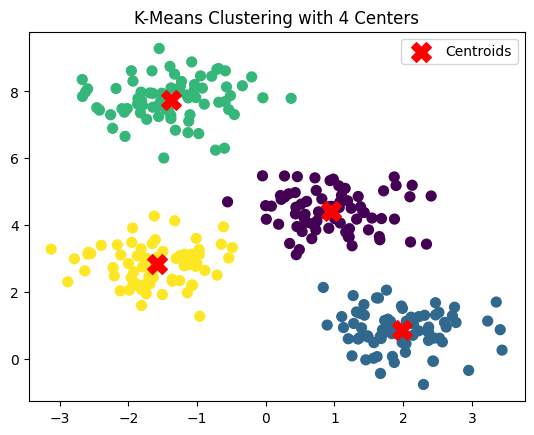

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Apply KMeans clustering
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

# 3. Visualize the results
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('K-Means Clustering with 4 Centers')
plt.legend()
plt.show()


7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Load and Scale
wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)

# Train DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Count clusters (excluding noise label -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters found: {n_clusters}")


Number of clusters found: 1


 8: Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.

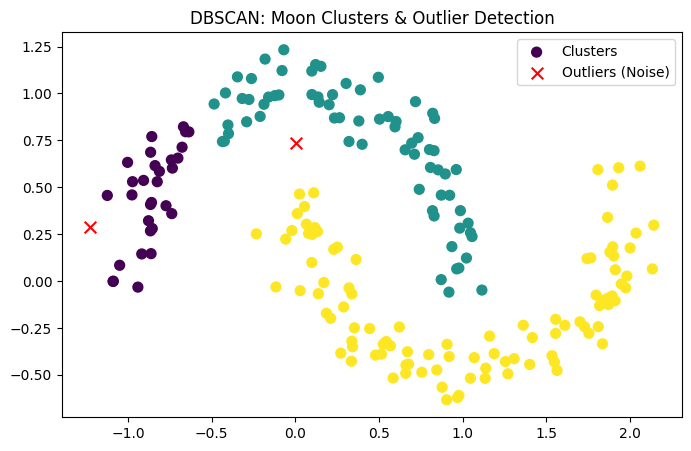

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# 1. Generate moon-shaped data
X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)

# 2. Apply DBSCAN
# eps: distance to neighbors; min_samples: min points to form a dense region
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Identify Clustered points vs. Outliers
outliers = X[labels == -1]
clustered = X[labels != -1]
cluster_labels = labels[labels != -1]

# 4. Visualization
plt.figure(figsize=(8, 5))

# Plot clustered data
plt.scatter(clustered[:, 0], clustered[:, 1], c=cluster_labels, cmap='viridis', s=50, label='Clusters')

# Highlight outliers in red with 'x' marker
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', marker='x', s=70, label='Outliers (Noise)')

plt.title('DBSCAN: Moon Clusters & Outlier Detection')
plt.legend()
plt.show()


 9: Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot.

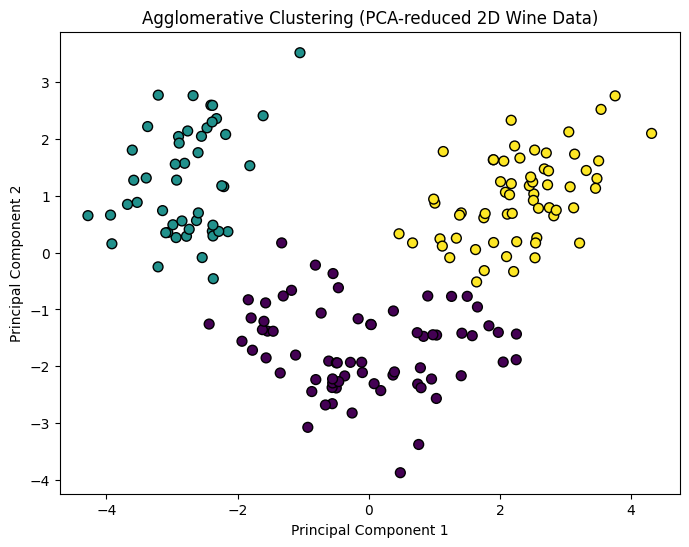

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Load and scale the data
wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_pca)

# Visualize with a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Agglomerative Clustering (PCA-reduced 2D Wine Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


 10: You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.


Describe your real-world data science workflow using clustering:


● Which clustering algorithm(s) would you use and why?


● How would you preprocess the data (missing values, scaling)?


● How would you determine the number of clusters?


● How would the marketing team benefit from your clustering analysis?





1. Preprocessing: Preparing the "Customer Feature Vector"


Before clustering, I would aggregate transaction-level data into a Customer-360 table (RFM model: Recency, Frequency, Monetary).


Handling Missing Values: For demographics (like age), I’d use median imputation. For purchase history, I’d fill missing categories with 0 (indicating no purchase) rather than deleting rows, to keep the full customer base.


Feature Engineering: I’d create "Category Affinity" scores (e.g., % of spend on Electronics vs. Fashion).


Scaling: I would use StandardScaler. Since "Monetary Value" might be $10,000 while "Recency" is 5 days, scaling ensures the spend amount doesn't over-influence the distance calculation.



2. Algorithm Selection: Why K-Means and DBSCAN?


K-Means (Primary): This is the industry standard for customer segmentation. It’s computationally fast for large e-commerce databases and creates easy-to-understand, distinct "circles" of customers.


DBSCAN (Secondary): I’d use this to identify outliers (extreme "Whales" who spend 100x more than average) or niche groups that don't fit the standard clusters, ensuring they don't skew the main marketing segments.



3. Determining the Number of Clusters (
)
I wouldn't rely on just one method; I’d use a "consensus" approach:


The Elbow Method: To find the mathematical point of diminishing returns.


Silhouette Score: To ensure the resulting segments are actually distinct and not overlapping.



Business Logic: If the math suggests 12 clusters but the marketing team only has the budget for 4 unique campaigns, I would settle on or to ensure the results are operationally feasible.



4. Business Impact for the Marketing Team
The "clusters" become "Personas." Instead of generic emails, the team can now:


The "At-Risk" Segment: Send "We miss you" discount codes to customers with high historical spend but high Recency (haven't visited in 6 months).


The "Budget Fashionistas": Promote seasonal sales on clothing to high-frequency, low-monetary shoppers.



The "VIPs": Invite the top 5% of spenders to a loyalty program or early-access events.